In [160]:
# importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [132]:
# reading the dataset
df = pd.read_csv("../data/salaries.csv")

In [133]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [134]:
# dropping the unneccessary columns
df.drop(columns = ['employment_type', 'job_title', 'company_location', 'company_size', 'employee_residence', 'salary_in_usd', 'salary_currency','job_title'], inplace = True)

In [135]:
df.head()

,work_year,experience_level,salary,remote_ratio
0,2025,EX,348516,0
1,2025,EX,232344,0
2,2025,SE,145400,0
3,2025,SE,81600,0
4,2025,MI,160000,100


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   work_year         151445 non-null  int64 
 1   experience_level  151445 non-null  object
 2   salary            151445 non-null  int64 
 3   remote_ratio      151445 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 4.6+ MB


In [137]:
df.shape

(151445, 4)

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   work_year         151445 non-null  int64 
 1   experience_level  151445 non-null  object
 2   salary            151445 non-null  int64 
 3   remote_ratio      151445 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 4.6+ MB


## EDA

In [139]:
df.describe()

,work_year,salary,remote_ratio
count,151445.000000,1.514450e+05,151445.000000
mean,2024.435313,1.628380e+05,20.938625
std,0.671842,2.080124e+05,40.620393
min,2020.000000,1.400000e+04,0.000000
25%,2024.000000,1.060000e+05,0.000000
50%,2025.000000,1.470000e+05,0.000000
75%,2025.000000,1.990000e+05,0.000000
max,2025.000000,3.040000e+07,100.000000


### Univariate Analysis

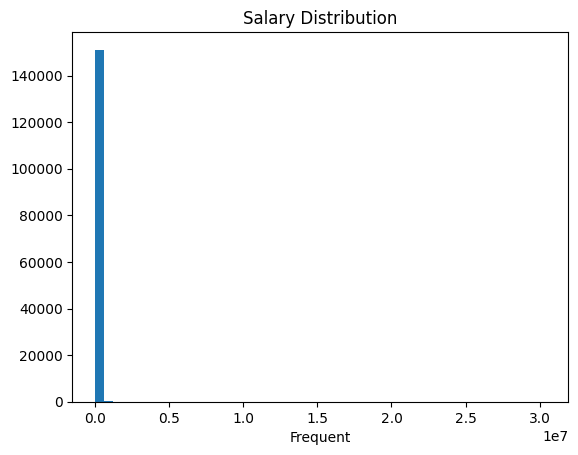

In [140]:
plt.hist(df['salary'], bins = 50)
plt.xlabel("Salary")
plt.xlabel("Frequent")
plt.title("Salary Distribution")
plt.show()

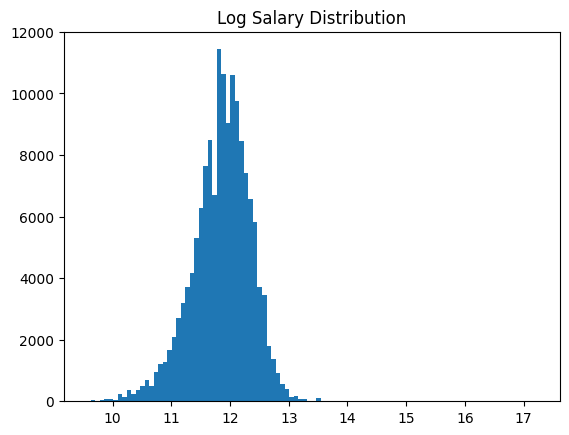

In [141]:
plt.hist(np.log1p(df['salary']), bins=100)
plt.title("Log Salary Distribution")
plt.show()

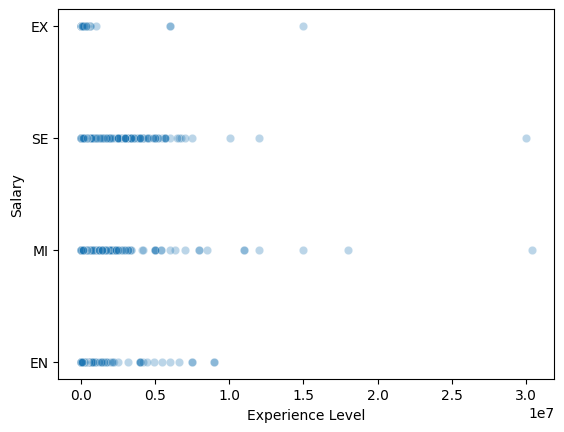

In [142]:
sns.scatterplot(x = df['salary'], y = df['experience_level'], alpha = 0.3)
plt.xlabel("Experience Level")
plt.ylabel("Salary")
plt.show()

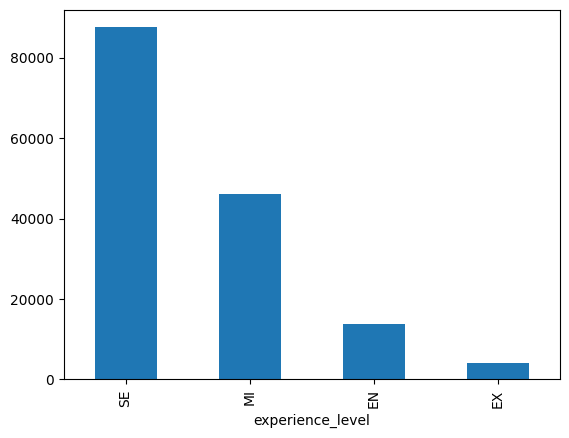

In [143]:
df['experience_level'].value_counts().plot(kind = 'bar')
plt.show()

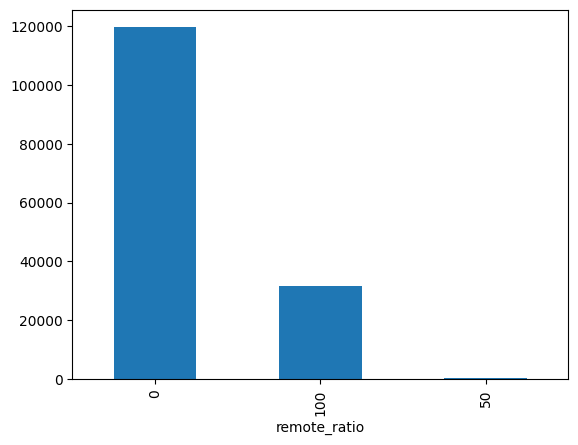

In [144]:
df['remote_ratio'].value_counts().plot(kind = 'bar')
plt.show()

### Bivariate Analysis

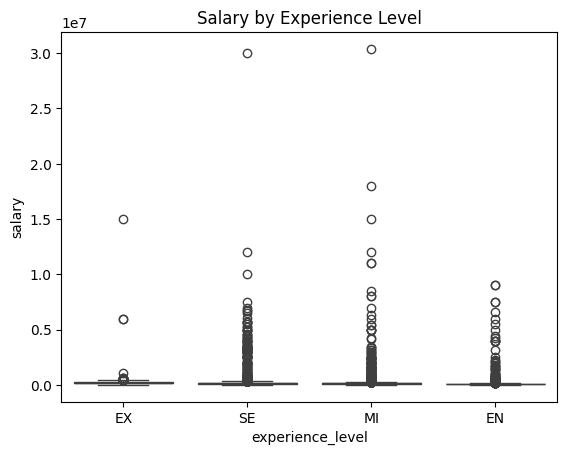

In [145]:
sns.boxplot(x = 'experience_level', y = 'salary', data = df)
plt.title("Salary by Experience Level")
plt.show()

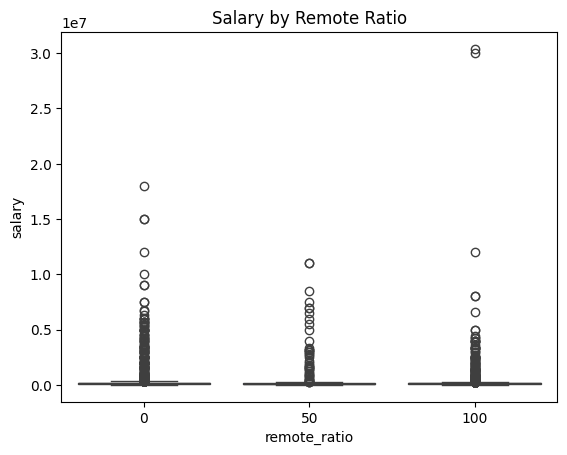

In [146]:
sns.boxplot(x = df['remote_ratio'], y = df['salary'])
plt.title("Salary by Remote Ratio")
plt.show()

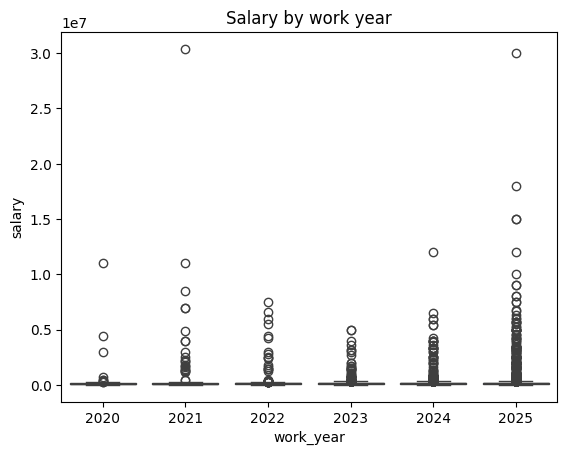

In [147]:
sns.boxplot(x = df['work_year'], y = df['salary'])
plt.title("Salary by work year")
plt.show()

## Encoding

In [148]:
exp_mapping = {
    'EN': 0,
    'MI': 1,
    'SE': 2,
    'EX': 3
}

In [149]:
# apply encoding
df['experience_level_enc'] = df['experience_level'].map(exp_mapping)

In [150]:
# dropping the exp level col
df.drop(columns = ['experience_level'], inplace = True)

## Log Transformation

In [151]:
# performing log operation
df['salary_log'] = np.log(df['salary'])

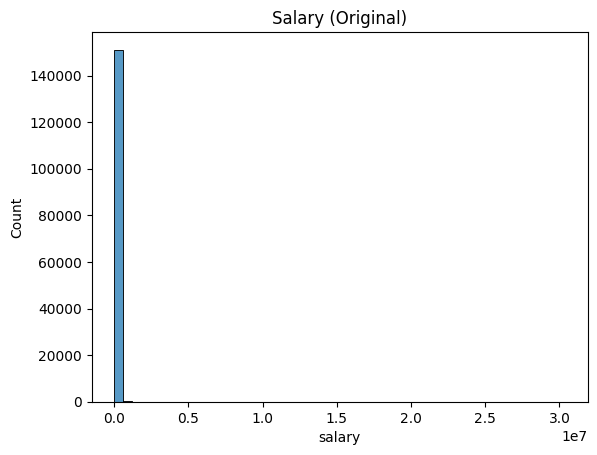

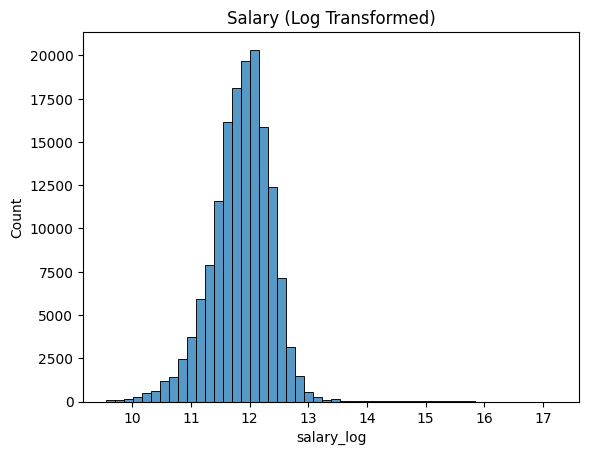

In [152]:
# comparing the distributions
sns.histplot(df['salary'], bins = 50)
plt.title("Salary (Original)")
plt.show()

sns.histplot(df['salary_log'], bins = 50)
plt.title("Salary (Log Transformed)")
plt.show()

## Train, Test & Split

In [153]:
# defining the target & feature columns
x = df.drop(columns = ['salary_log', 'salary'])
y = df['salary_log']

In [154]:
# splitting the dataset
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.2)

In [155]:
# checking the shape
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(121156, 3)
(30289, 3)
(121156,)
(30289,)


## Model Training & Prediction

In [157]:
# initiating the algorithm
lr = LinearRegression()

In [158]:
# fitting the dataset
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [159]:
# predicting the salary
y_pred = lr.predict(x_test)

## Evaluating the post 

In [162]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 0.47026166051322654
R2 Score: 0.13497502559745544
